## Introduction

#### This is an implimentation of GEO Algorithm (Generator enhanced optimization) proposed in the paper - https://arxiv.org/abs/2101.06250.
Using this algorithm I optimized a very simple problem. It can be used in various other problems including portfolio optimization.
For another example check out my github - https://github.com/cozmoguy/GEO-Implementation

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.multivariate_normal import MultivariateNormal
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else 'cpu'

In [24]:
import random
import numpy as np
import pandas as pd

## Problem/Cost_function definition

The problem is to optimize a mathematical equation - $\sqrt{{{x_1}^2+{x_2}^2+{x_3}^2+{x_4}^2+{x_5}^2}}$

In [25]:
def objective(x):
    return torch.sqrt(torch.square(x).sum(dim=1)).to(device)


## Initial Seed

In [26]:
initial_seed = torch.rand(1000,5) * 2 - 1
initial_seed = initial_seed.to(device)

In [27]:
objective(initial_seed).min()

tensor(0.2987)

## Distribution Constructor

In [28]:
def multiDistribution(data_seed):
  mean = torch.mean(data_seed, axis=0)
  covariance = torch.cov(torch.permute(data_seed, (1, 0)))
  distribution = MultivariateNormal(loc=mean, covariance_matrix=covariance)
  return distribution

In [29]:
distri = multiDistribution(initial_seed)

In [30]:
distri.sample()

tensor([ 0.0854, -0.7839,  0.8436,  0.7936,  0.1051])

## Generative model

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, latent_dim)  # Mean of the latent distribution
        self.fc22 = nn.Linear(hidden_dim, latent_dim)  # Log variance of the latent distribution

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)  # Return mean and log variance

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)  # Standard deviation
        eps = torch.randn_like(std)  # Sampling from normal distribution
        return mu + eps * std  # Reparameterization trick

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))  # Sigmoid to get reconstructed output between [0, 1]

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar  # Return the reconstructed output and the parameters of the latent distribution

def vae_loss(recon_x, x, mu, logvar):
    # Ensure the target values (x) are between 0 and 1
    x = torch.clamp(x, 0.0, 1.0)  # Clip the values to be within [0, 1]

    # Binary Cross Entropy loss for reconstruction
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')  # Sum over the batch

    # KL Divergence loss between the learned distribution and standard normal distribution
    KL_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # The total VAE loss is the sum of both reconstruction loss and KL divergence
    return BCE + KL_div


In [32]:
def generate_random_noise(batch_size, sample_dim):
    return torch.randn(batch_size, sample_dim).to(device)

In [33]:
sample_dim = 5
latent_dim = 5
hidden_dim = 3
batch_size = 64
num_epochs = 500
learning_rate = 0.0002

vae = VAE(sample_dim, hidden_dim, latent_dim).to(device)
vae_optimizer = optim.Adam(vae.parameters(), lr=learning_rate)

In [34]:
criterion = nn.BCELoss()

## Training Loop

In [35]:
from tqdm import tqdm

In [36]:
pbar = tqdm(range(num_epochs))
new_gens = np.array([])
initial_seed_obj = objective(initial_seed)
ground_val = initial_seed_obj.min().item()
distri = multiDistribution(initial_seed)
costs = []
means = []
stds = []

for epoch in pbar:
    if new_gens.any():
        initial_seed = torch.cat((initial_seed, new_gens), dim=0)
        initial_seed_obj = objective(initial_seed)
        sort_ind = torch.sort(initial_seed_obj, dim=0)[1]
        initial_seed = initial_seed[sort_ind]
        initial_seed = initial_seed[:1000]
        ground_val = initial_seed_obj.min().item()

        distri = multiDistribution(initial_seed)
        new_gens = np.array([])

    mean, std = torch.mean(initial_seed_obj), torch.std(initial_seed_obj)

    for batch_idx in range(1000 // batch_size):
        # Sample from the distribution
        real_samples = distri.sample(sample_shape=[batch_size*10]).to(device).float()
        real_samples = real_samples[:batch_size, :]

        # Forward pass through VAE
        vae_optimizer.zero_grad()

        # Encoding and decoding
        recon_samples, mu, logvar = vae(real_samples)

        # Compute VAE loss
        loss = vae_loss(recon_samples, real_samples, mu, logvar)

        # Backpropagate and optimize VAE
        loss.backward()
        vae_optimizer.step()

    # Generate new samples using VAE decoder
    new_gens = vae.decode(torch.randn(100, latent_dim).to(device)).detach()

    pbar.set_description(f"{round(loss.item(), 2)} :: {round(mean.item(), 2)} :: {round(std.item(), 2)} :: {ground_val}")
    costs.append(ground_val)
    means.append(mean.item())
    stds.append(std.item())


153.82 :: 0.46 :: 0.01 :: 0.2986786961555481: 100%|██████████| 500/500 [00:25<00:00, 19.46it/s]


In [43]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import statistics
import numpy as np
def plot_training_curves(results):
    min_cost = results["min_cost"]
    cost_mean = results["cost_mean"]

    epochs = range(len(results["min_cost"]))

    plt.figure(figsize=(10, 7))

    plt.plot(epochs, min_cost, label="min_cost")
    plt.plot(epochs, cost_mean, label="cost_mean")
    plt.title("Cost Value")
    plt.xlabel("Epochs")
    plt.legend()
    plt.grid()

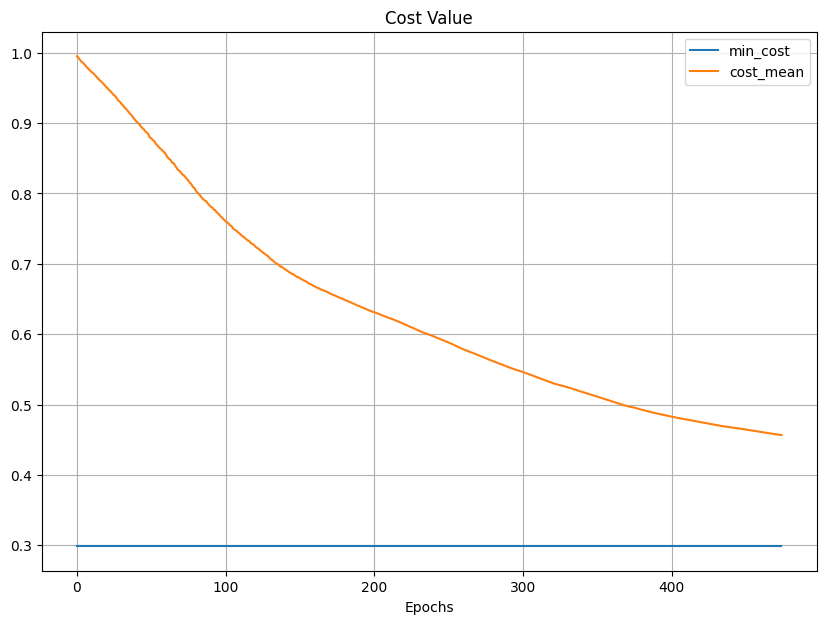

In [44]:
plot_training_curves({
    'min_cost':costs[25:],
    'cost_mean':means[25:]
})